## Overview

This notebook builds a synthetic multi-asset portfolio with known ground truth. The point is to have something where I know the "true" underlying price dynamics, so later I can check whether the Kalman filter and HMM are actually recovering that signal before testing them on real financial data.

Four correlated assets, each with its own drift and volatility:

- EQTY, generic equity
- BOND, fixed income
- GOLD, safe haven commodity
- TECH, higher growth, higher volatility

In [5]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from dataclasses import dataclass

import sys
sys.path.append("../src")

# This file contains code that helps me create
# market data based on imposed values
from simulate_gbm_market import Asset, simulate_gbm_market

ModuleNotFoundError: No module named 'yfinance'

In [ ]:
# Definition of assets
# mu being expected returns and sigma being volatility
assets = [
    Asset("EQTY", mu=0.07, sigma=0.18),
    Asset("BOND", mu=0.03, sigma=0.05),
    Asset("GOLD", mu=0.02, sigma=0.15),
    Asset("TECH", mu=0.12, sigma=0.35),
]

# We create a correlation matrix, as a standard equity portfolio will have significant overlap with tech    
corr = np.array([
    [1.00,  -0.30, 0.05, 0.55],
    [-0.30,  1.00, 0.10, -0.25],
    [0.05,   0.10, 1.00, 0.00],
    [0.55,  -0.25, 0.00, 1.00],
])

# We create starting values for our simulation, indexing everything to 100
s0 = np.array([100, 100, 100, 100])

Now that we have initial conditions set up we create a function that let's us simulate a market using brownian motion
Having done some research I know the best way to make them correlate with eachother is to go take a second look on cholesky decompositions

In [ ]:
# Simulates correlated geometric Brownian Motion for N assets.
# Each asset gets assigned a drift and a volatility
# Correlation imposed using cholesky

# Run it
prices = simulate_gbm_market(assets, corr, s0, n_days=1000, seed=None)
prices.head()

,EQTY,BOND,GOLD,TECH
2023-01-02,100.468725,99.925930,99.036536,99.192573
2023-01-03,101.103727,99.987337,98.806665,99.133226
2023-01-04,99.299676,99.957337,98.971929,96.126216
2023-01-05,99.459117,99.836767,99.118693,98.129782
2023-01-06,98.863125,100.203243,100.543569,97.770381


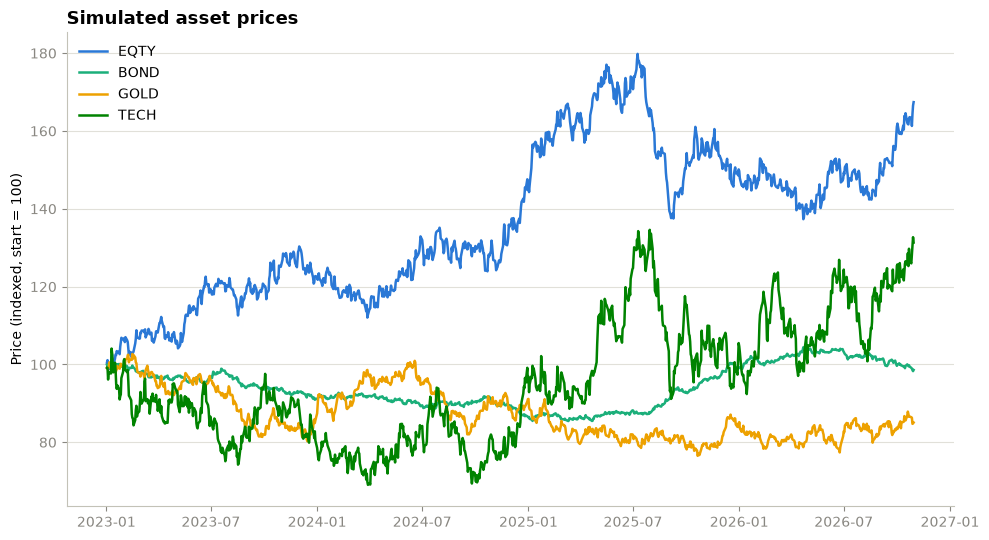

In [ ]:
COLORS = ["#2a78d6", "#1baf7a", "#eda100", "#008300"]

fig, ax = plt.subplots(figsize=(10, 5.5))

for ticker, color in zip(prices.columns, COLORS):
    ax.plot(prices.index, prices[ticker], color=color, linewidth=1.8, label=ticker)

ax.set_title("Simulated asset prices", fontsize=13, fontweight="bold", loc="left")
ax.set_ylabel("Price (indexed, start = 100)")

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):
    ax.spines[spine].set_color("#c3c2b7")

ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(colors="#898781")

ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()

**We now have a reliable way to simulate the markets from from our known outputs**
The next step is to make a Kalman filter to retrive the underlying data

**Because we know the actual underlying characteristics of this data, we can use it to tune the parameters of our Kalman filter**, we just have to be careful not to overfit the data.

### The Kalman filter

#### Method
We will be using the priniples of observers as I've been taught in my uni lessons at INSA Toulouse


**States** \
In this demonstation my why two states will be position and velocity, represented here as the assets price and rate of change

**Filter** \
The Kalman filter is defined by it's Q and R matrices. Q can be describes as a cost matrix, and R as a cost matrix. The Q/R ratio describes the filter gain.

My experiece with obervators and controllers is that with a high Q/R ratio you get the best performance. The downside is that by chasing high performance you might get an uncontrolled system. E.G a pendelum that overcorrects and therefore does not stabilize. If you're too conservative and chose a weak Q/R gain, the system trusts it's own model too much and it wanders of, leading to another instable system.

**Intuitions for finance** \
High Q/R might not filter enough noise to be useful \
Low Q/R might wander of and present false data \

I suspect the Q/R needs to be ajusted for each and every asset, as a more volatile asset groups might need a weaker Q/R gain.